In [177]:
import numpy as np 
import matplotlib.pyplot as plt 

In [178]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

In [179]:
class Perceptron:
    def __init__(self, input_size, lr = 0.1, epochs = 10):
        self.w = np.random.rand(input_size)
        self.b = np.zeros(1)
        self.input_size = input_size
        self.lr = lr
        self.epochs = epochs
    
    def step_function(self, z):
        if z >= 0:
            return 1
        else:
            return 0
    
    def forward(self, x):
        z = x @ self.w + self.b
        return self.step_function(z)
    
    def training(self, x, y):
        for epoch in range(self.epochs):
            for i, x_i in enumerate(x):
                y_pred = self.forward(x_i)

                error = y[i] - y_pred

                self.w += self.lr * error * x_i
                self.b += self.lr * error

In [180]:
perceptron = Perceptron(2, 0.001, 10)
perceptron.training(X, y)

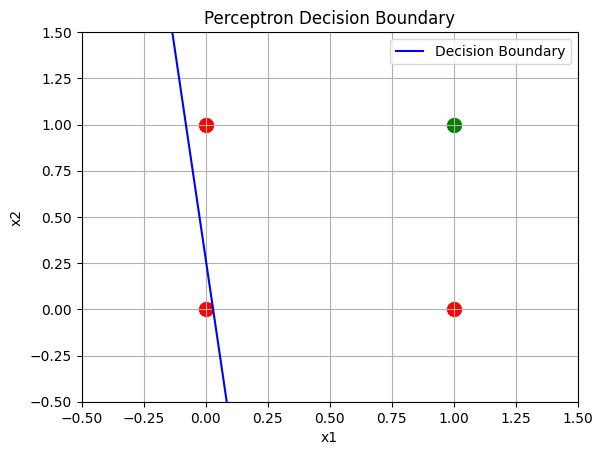

In [181]:
import matplotlib.pyplot as plt
import numpy as np

# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', s=100)
    else:
        plt.scatter(X[i][0], X[i][1], color='green', s=100)

# Get weights and bias
w = perceptron.w
b = perceptron.b

# Decision boundary: w0*x1 + w1*x2 + b = 0
x_vals = np.array([-0.5, 1.5])

if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
    plt.plot(x_vals, y_vals, 'b-', label='Decision Boundary')
else:
    plt.axvline(x=-b / w[0], color='blue', label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")
plt.grid(True)
plt.legend()

plt.show()